Machine Learning - N1
**Dataset:** Feminicídio no Brasil (2015–2025)  


-------
## CÉLULA 1: IMPORTAÇÃO DE BIBLIOTECAS


In [2]:
print("🚀 Bem-vindos ao Aprendizado de Máquina Supervisionado!")
print("=" * 60)

# Importar bibliotecas
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

print("✅ Todas as bibliotecas foram importadas com sucesso!")


🚀 Bem-vindos ao Aprendizado de Máquina Supervisionado!
✅ Todas as bibliotecas foram importadas com sucesso!


-----------
##📚 CÉLULA 2: CONCEITO FUNDAMENTAL

Resumo executivo: Coleta e análise

In [13]:
print("1. Evolução da Notificação (O Efeito da Lei):")
print("---------------------------------------------")
print("* O salto nos Casos Registrados (de 449 em 2015 para 1.568 em 2025) não indica necessariamente que o crime não ocorria antes, mas sim o sucesso da implementação da Lei 13.104/15.")
print("* Os primeiros anos (2015-2017) mostram dados baixos ou nulos em tentativas porque as delegacias ainda estavam aprendendo a tipificar o crime.(Usamos NaN para indentificar os dados Nulos.)")
print("* A partir de 2018, os dados tornam-se robustos, culminando em um aumento expressivo nas tentativas em 2024/2025, o que reflete maior confiança das mulheres em denunciar e melhor preparo policial.")
print("---------------------------------------------")
print("O Perfil da Vítima: Recorte Racial")
print("    O dado mais estável e preocupante da coleta é o de vítimas negras.")
print("* Durante toda a década, o percentual se manteve acima de 60%, com picos de 66,6%.")
print("* Isso evidencia que a violência de gênero no Brasil tem uma camada profunda de desigualdade racial, onde mulheres negras permanecem sendo o grupo mais vulnerável e menos alcançado por políticas de proteção.")
print("---------------------------------------------")
print("O Agressor: O Perigo dentro de Casa")
print("    A coluna de mortas pelo companheiro ou ex revela que o feminicídio é um crime de proximidade.")
print("* Os índices são altíssimos, chegando a 97% em 2024.")
print("* O 'vale' estatístico em 2020 (81,5%) é um ponto de atenção: a pandemia dificultou a investigação da autoria no momento do crime, mas a tendência histórica confirma que o lar é, infelizmente, o local de maior risco.")
print("---------------------------------------------")

1. Evolução da Notificação (O Efeito da Lei):
---------------------------------------------
* O salto nos Casos Registrados (de 449 em 2015 para 1.568 em 2025) não indica necessariamente que o crime não ocorria antes, mas sim o sucesso da implementação da Lei 13.104/15.
* Os primeiros anos (2015-2017) mostram dados baixos ou nulos em tentativas porque as delegacias ainda estavam aprendendo a tipificar o crime.(Usamos NaN para indentificar os dados Nulos.)
* A partir de 2018, os dados tornam-se robustos, culminando em um aumento expressivo nas tentativas em 2024/2025, o que reflete maior confiança das mulheres em denunciar e melhor preparo policial.
---------------------------------------------
O Perfil da Vítima: Recorte Racial
    O dado mais estável e preocupante da coleta é o de vítimas negras.
* Durante toda a década, o percentual se manteve acima de 60%, com picos de 66,6%.
* Isso evidencia que a violência de gênero no Brasil tem uma camada profunda de desigualdade racial, onde mu

---
## 2. Coleta de Dados
**Decisão:** Dataset carregado a partir de arquivo CSV com separador `;`, contendo registros anuais de feminicídio no Brasil de 2015 a 2025.

In [14]:
# Faça upload do arquivo CSV quando solicitado ou ajuste o caminho abaixo
from google.colab import files
uploaded = files.upload()

Saving feminicidio_brasil_ml (1)(Planilha2) 2(in).csv to feminicidio_brasil_ml (1)(Planilha2) 2(in) (1).csv


In [15]:
# Carregamento do dataset
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename, sep=';')

print(f'Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas')
df

Dataset carregado: 11 linhas x 6 colunas


,ano,casos_registrados,tentativas_feminicidio,vitimas_negras,mortas_pelo_companheiroOuEx,denuncia_feminicidio
0,2015,449,NaN,0.618,0.834,76651
1,2016,929,NaN,0.611,0.851,113343
2,2017,1075,NaN,0.601,0.860,155000
3,2018,1229,2053.0,0.610,0.888,92657
4,2019,1330,2321.0,0.666,0.899,85000
5,2020,1354,2164.0,0.618,0.815,105671
6,2021,1347,2321.0,0.620,0.820,81000
7,2022,1455,2564.0,0.611,0.847,87000
8,2023,1475,2797.0,0.633,0.902,114611
9,2024,1492,3870.0,0.640,0.970,132084


---
## 3. Limpeza de Dados

### 3.1 Inspeção inicial

In [16]:
print('=== Tipos de dados ===')
print(df.dtypes)
print()
print('=== Valores nulos por coluna ===')
print(df.isnull().sum())
print()
print('=== Estatísticas descritivas ===')
df.describe()

=== Tipos de dados ===
ano                              int64
casos_registrados                int64
tentativas_feminicidio         float64
vitimas_negras                 float64
mortas_pelo_companheiroOuEx    float64
denuncia_feminicidio             int64
dtype: object

=== Valores nulos por coluna ===
ano                            0
casos_registrados              0
tentativas_feminicidio         3
vitimas_negras                 0
mortas_pelo_companheiroOuEx    0
denuncia_feminicidio           0
dtype: int64

=== Estatísticas descritivas ===


,ano,casos_registrados,tentativas_feminicidio,vitimas_negras,mortas_pelo_companheiroOuEx,denuncia_feminicidio
count,11.000000,11.000000,8.000000,11.000000,11.000000,11.000000
mean,2020.000000,1245.727273,2855.625000,0.623091,0.876364,108920.727273
std,3.316625,324.726066,957.620852,0.018019,0.051585,28273.671343
min,2015.000000,449.000000,2053.000000,0.601000,0.815000,76651.000000
25%,2017.500000,1152.000000,2281.750000,0.611000,0.840500,86000.000000
50%,2020.000000,1347.000000,2442.500000,0.618000,0.860000,105671.000000
75%,2022.500000,1465.000000,3065.250000,0.629500,0.900500,123347.500000
max,2025.000000,1568.000000,4755.000000,0.666000,0.970000,155111.000000


### 3.2 Tratamento de valores ausentes
**Decisão:** A coluna `tentativas_feminicidio` possui NaN nos anos 2015, 2016 e 2017 porque o registro sistemático dessa informação só passou a existir após a regulamentação da Lei do Feminicídio. Os valores são mantidos como NaN, pois imputação distorceria a série histórica.

In [27]:
# Verificar quais linhas possuem NaN
print('Linhas com valores ausentes:')
print(df[df.isnull().any(axis=1)])

# verificação de duplicatas
duplicatas = df.duplicated().sum()
print(f'Linhas duplicadas: {duplicatas}')

anos_duplicados = df['ano'].duplicated().sum()
print(f'Anos duplicados: {anos_duplicados}')

#  Verificação de consistência dos valores

# Colunas de proporção devem estar entre 0 e 1
colunas_proporcao = ['vitimas_negras', 'mortas_pelo_companheiroOuEx']
for col in colunas_proporcao:
    fora_intervalo = df[(df[col] < 0) | (df[col] > 1)]
    print(f'{col}: {len(fora_intervalo)} valores fora de [0, 1]')

# Colunas inteiras não devem ter negativos
colunas_contagem = ['casos_registrados', 'denuncia_feminicidio']
for col in colunas_contagem:
    negativos = df[df[col] < 0]
    print(f'{col}: {len(negativos)} valores negativos')

Linhas com valores ausentes:
    ano  casos_registrados  tentativas_feminicidio  vitimas_negras  \
0  2015                449                     NaN           0.618   
1  2016                929                     NaN           0.611   
2  2017               1075                     NaN           0.601   

   mortas_pelo_companheiroOuEx  denuncia_feminicidio  
0                        0.834                 76651  
1                        0.851                113343  
2                        0.860                155000  
Linhas duplicadas: 0
Anos duplicados: 0
vitimas_negras: 0 valores fora de [0, 1]
mortas_pelo_companheiroOuEx: 0 valores fora de [0, 1]
casos_registrados: 0 valores negativos
denuncia_feminicidio: 0 valores negativos


---
## 4. Distribuição Antes da Normalização
**Dica da rubrica:** Plotar distribuições antes e depois.

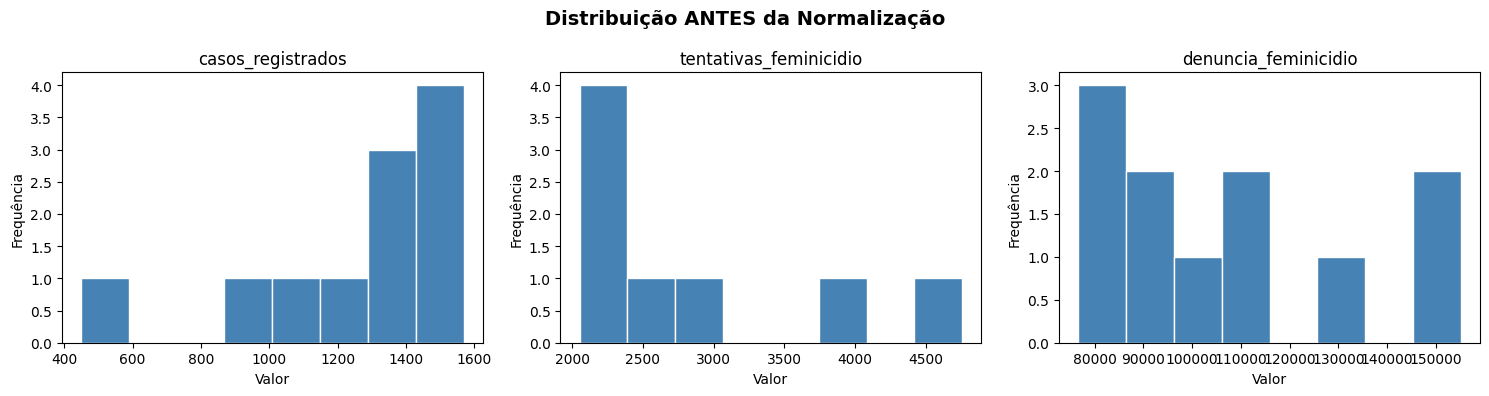

Gráfico salvo como distribuicao_antes.png


In [20]:
colunas_numericas = ['casos_registrados', 'tentativas_feminicidio', 'denuncia_feminicidio']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribuição ANTES da Normalização', fontsize=14, fontweight='bold')

for ax, col in zip(axes, colunas_numericas):
    df[col].dropna().plot(kind='hist', ax=ax, bins=8, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frequência')

plt.tight_layout()
plt.savefig('distribuicao_antes.png', dpi=150)
plt.show()
print('Gráfico salvo como distribuicao_antes.png')

---
## 5. Normalização e Padronização
**Decisão:** São aplicados dois métodos:
- **MinMaxScaler** (normalização 0–1): indicado para algoritmos sensíveis à escala como KNN e redes neurais.
- **StandardScaler** (z-score, média 0 e desvio padrão 1): indicado para regressão, SVM e algoritmos que assumem distribuição gaussiana.

As colunas `vitimas_negras` e `mortas_pelo_companheiroOuEx` já estão em escala [0,1] e são mantidas sem transformação adicional. A coluna `ano` é excluída por ser identificadora temporal.

In [28]:
# Colunas a normalizar (excluindo ano e colunas já em [0,1])
colunas_para_normalizar = ['casos_registrados', 'tentativas_feminicidio', 'denuncia_feminicidio']

# --- MinMax Scaler ---
df_minmax = df.copy()
scaler_minmax = MinMaxScaler()
df_minmax[colunas_para_normalizar] = scaler_minmax.fit_transform(df[colunas_para_normalizar])

print('=== MinMaxScaler aplicado ===')
print(df_minmax[colunas_para_normalizar].describe().round(4))

# --- Standard Scaler ---
df_standard = df.copy()
scaler_standard = StandardScaler()
df_standard[colunas_para_normalizar] = scaler_standard.fit_transform(df[colunas_para_normalizar])

print('=== StandardScaler aplicado ===')
print(df_standard[colunas_para_normalizar].describe().round(4))

=== MinMaxScaler aplicado ===
       casos_registrados  tentativas_feminicidio  denuncia_feminicidio
count            11.0000                  8.0000               11.0000
mean              0.7120                  0.2970                0.4113
std               0.2902                  0.3544                0.3604
min               0.0000                  0.0000                0.0000
25%               0.6282                  0.0847                0.1192
50%               0.8025                  0.1442                0.3699
75%               0.9080                  0.3746                0.5952
max               1.0000                  1.0000                1.0000
=== StandardScaler aplicado ===
       casos_registrados  tentativas_feminicidio  denuncia_feminicidio
count            11.0000                  8.0000               11.0000
mean             -0.0000                  0.0000               -0.0000
std               1.0488                  1.0690                1.0488
min            

---
## 6. Distribuição Depois da Normalização

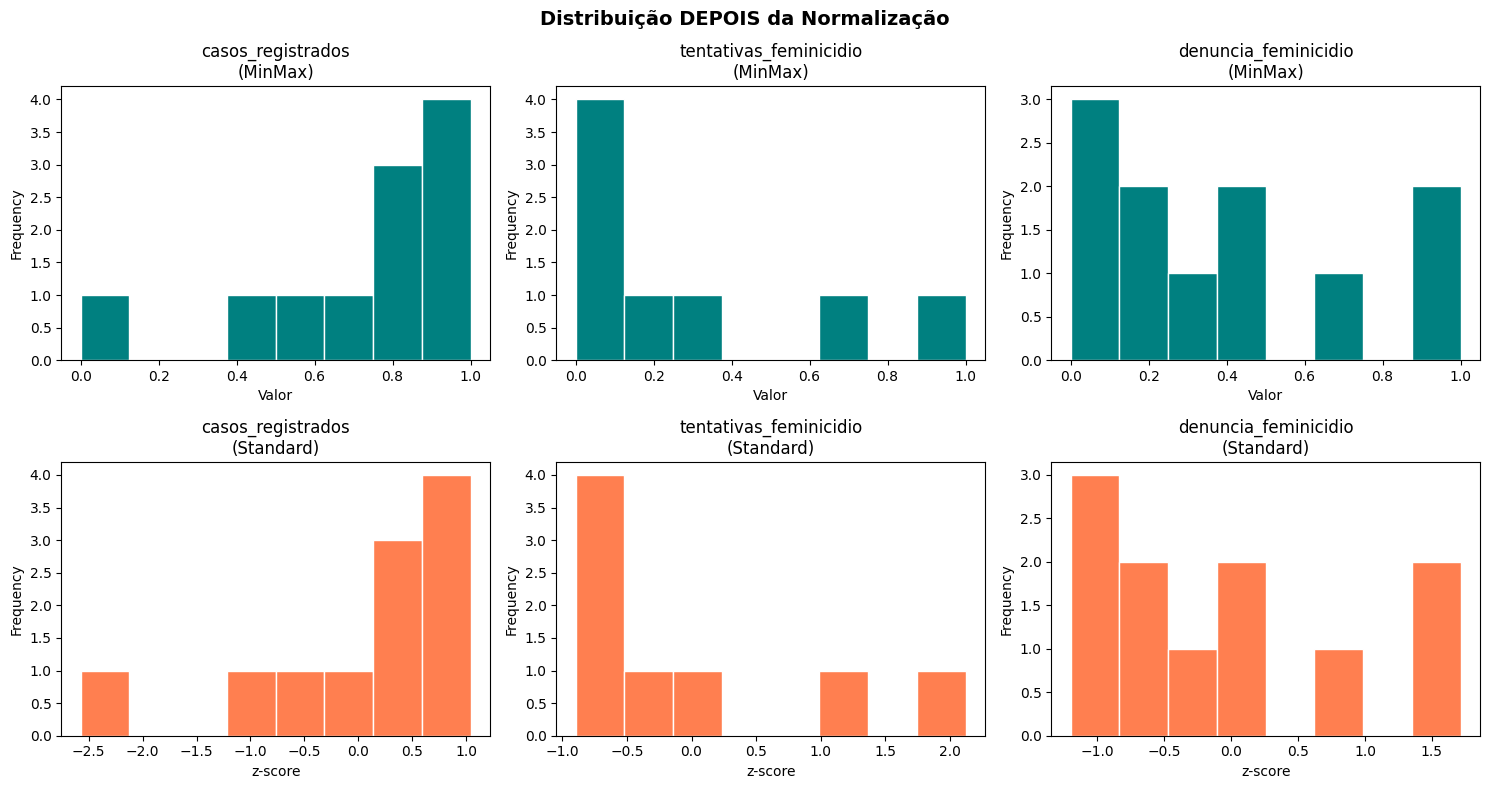

Gráfico salvo como distribuicao_depois.png


In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribuição DEPOIS da Normalização', fontsize=14, fontweight='bold')

for i, col in enumerate(colunas_para_normalizar):
    # MinMax
    df_minmax[col].dropna().plot(kind='hist', ax=axes[0, i], bins=8, color='teal', edgecolor='white')
    axes[0, i].set_title(f'{col}\n(MinMax)')
    axes[0, i].set_xlabel('Valor')

    # Standard
    df_standard[col].dropna().plot(kind='hist', ax=axes[1, i], bins=8, color='coral', edgecolor='white')
    axes[1, i].set_title(f'{col}\n(Standard)')
    axes[1, i].set_xlabel('z-score')

plt.tight_layout()
plt.savefig('distribuicao_depois.png', dpi=150)
plt.show()
print('Gráfico salvo como distribuicao_depois.png')

---
## 7. Dataset Final

In [29]:
print('=== Dataset original (limpo) ===')
print(df.to_string())
print()
print('=== Dataset normalizado (MinMax) ===')
print(df_minmax.to_string())
print()
print('=== Dataset padronizado (Standard) ===')
print(df_standard.to_string())

# Exportar datasets processados
df_minmax.to_csv('feminicidio_minmax.csv', index=False, sep=';')
df_standard.to_csv('feminicidio_standard.csv', index=False, sep=';')
print('Arquivos exportados: feminicidio_minmax.csv e feminicidio_standard.csv')

=== Dataset original (limpo) ===
     ano  casos_registrados  tentativas_feminicidio  vitimas_negras  mortas_pelo_companheiroOuEx  denuncia_feminicidio
0   2015                449                     NaN           0.618                        0.834                 76651
1   2016                929                     NaN           0.611                        0.851                113343
2   2017               1075                     NaN           0.601                        0.860                155000
3   2018               1229                  2053.0           0.610                        0.888                 92657
4   2019               1330                  2321.0           0.666                        0.899                 85000
5   2020               1354                  2164.0           0.618                        0.815                105671
6   2021               1347                  2321.0           0.620                        0.820                 81000
7   2022       

---
## 8. Resumo das Decisões (Documentação)

| Etapa | Decisão | Justificativa |
|---|---|---|
| Coleta | CSV com separador `;` | Formato original do dataset |
| Valores ausentes | NaN mantido em `tentativas_feminicidio` (2015–2017) | Dado inexistente antes da regulamentação da lei |
| Duplicatas | Nenhuma encontrada | Dataset verificado |
| Colunas de proporção | Sem transformação (`vitimas_negras`, `mortas_pelo_companheiroOuEx`) | Já estão em escala [0,1] |
| Normalização | MinMaxScaler em contagens | Para algoritmos sensíveis à escala (KNN, redes neurais) |
| Padronização | StandardScaler em contagens | Para algoritmos que assumem distribuição gaussiana (regressão, SVM) |
| Coluna `ano` | Excluída da normalização | Variável identificadora temporal, não é feature |

**Fonte dos dados:** Registros oficiais de feminicídio no Brasil — Fórum Brasileiro de Segurança Pública / SSPs estaduais.